# Phase 2 — Supervisor + Router + Market Research

> **Gemini-only project.** Run this top-to-bottom AFTER Phase 2 is built. **Restart the kernel first if you've pulled new code.**

**Goal:** watch the supervisor route queries to the right agent and render the multi-agent graph.

**Note:** mixed query uses `CLT-002` (it holds NVDA). Heads-up: several LLM calls run here — if you hit a Gemini 429 rate limit, wait a minute and re-run the cell (Phase 3 adds rate limiting).


In [1]:
# --- Setup: load .env and make the project importable ---
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from dotenv import load_dotenv
load_dotenv('../.env')
assert os.getenv('GOOGLE_API_KEY'), 'Set GOOGLE_API_KEY in .env'
print('env loaded OK')

env loaded OK


## 1. Build the supervisor graph (Builder pattern)

In [2]:
from app.graph.builder import GraphBuilder
graph = (GraphBuilder()
         .with_supervisor()
         .with_portfolio_agent()
         .with_market_research_agent()
         .build())
print('graph compiled')

graph compiled


## 2. A helper that runs a query and traces which agents fire

In [3]:
from langchain_core.messages import AIMessage, HumanMessage
from app.agents.base import _text

def run_and_trace(client_id, query):
    visited, answers = [], {}
    state = {'messages': [HumanMessage(content=query)], 'client_id': client_id,
             'session_id': 'nb-2'}
    for chunk in graph.stream(state, stream_mode='updates'):
        for node, update in chunk.items():
            if node == 'supervisor':
                print(f'  supervisor -> {(update or {}).get("route")}')
            else:
                visited.append(node); print(f'  {node} ran')
            for m in (update or {}).get('messages', []):
                if isinstance(m, AIMessage) and m.content and _text(m.content).strip():
                    answers[node] = _text(m.content)   # keep EACH agent's final say
    return visited, answers


## 3. Acceptance queries — routing decisions

In [4]:
print('Q1: What stocks do I own?')
agents1, a1 = run_and_trace('CLT-002', 'What stocks do I own?')
for agent, ans in a1.items(): print(f'\n[{agent}]', ans[:300])

AFC is enabled with max remote calls: 10.


Q1: What stocks do I own?


HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-flash-lite:generateContent "HTTP/1.1 200 OK"


{"strategy": "llm", "decision": "portfolio", "event": "route_decision", "client_id": "CLT-002", "session_id": "nb-2", "agent": "supervisor", "level": "info", "timestamp": "2026-07-12T13:58:33.574618Z"}
{"next_agent": "portfolio", "hop": 1, "event": "supervisor_dispatch", "client_id": "CLT-002", "session_id": "nb-2", "agent": "supervisor", "level": "info", "timestamp": "2026-07-12T13:58:33.575678Z"}
  supervisor -> portfolio
{"query": "What stocks do I own?", "event": "agent_start", "client_id": "CLT-002", "session_id": "nb-2", "agent": "portfolio", "level": "info", "timestamp": "2026-07-12T13:58:33.578467Z"}


HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-flash-lite:generateContent "HTTP/1.1 200 OK"


...

{"seconds": 1.71, "new_messages": 3, "tool_calls": 1, "event": "agent_done", "client_id": "CLT-002", "session_id": "nb-2", "agent": "portfolio", "level": "info", "timestamp": "2026-07-12T13:58:35.287872Z"}


AFC is enabled with max remote calls: 10.


  portfolio ran


HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-flash-lite:generateContent "HTTP/1.1 200 OK"


{"strategy": "llm", "decision": "END", "event": "route_decision", "client_id": "CLT-002", "session_id": "nb-2", "agent": "supervisor", "level": "info", "timestamp": "2026-07-12T13:58:35.919290Z"}
{"hops": 1, "event": "supervisor_end", "client_id": "CLT-002", "session_id": "nb-2", "agent": "supervisor", "level": "info", "timestamp": "2026-07-12T13:58:35.920232Z"}
  supervisor -> END

[portfolio] You own the following holdings, grouped by asset class:

**Individual Stocks**
*   MSFT (Microsoft Corporation)
*   NVDA (NVIDIA Corporation)
*   TSLA (Tesla Inc)

**ETFs**
*   ARKK (ARK Innovation ETF)
*   QQQ (Invesco QQQ Trust ETF)
*   VEA (Vanguard FTSE Developed Markets ETF)

**Cash Equivalents


In [9]:
print('Q2: What is happening in the semiconductor sector today?')
agents2, a2 = run_and_trace('CLT-002', 'What is happening in the semiconductor sector today?')
for agent, ans in a2.items(): print(f'\n[{agent}]', ans[:300])

AFC is enabled with max remote calls: 10.


Q2: What is happening in the semiconductor sector today?


HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-flash-lite:generateContent "HTTP/1.1 200 OK"


{"strategy": "llm", "decision": "market_research", "event": "route_decision", "client_id": "CLT-002", "session_id": "nb-2", "agent": "supervisor", "level": "info", "timestamp": "2026-07-12T14:00:04.774738Z"}
{"next_agent": "market_research", "hop": 1, "event": "supervisor_dispatch", "client_id": "CLT-002", "session_id": "nb-2", "agent": "supervisor", "level": "info", "timestamp": "2026-07-12T14:00:04.775626Z"}
  supervisor -> market_research
{"query": "What is happening in the semiconductor sector today?", "event": "agent_start", "client_id": "CLT-002", "session_id": "nb-2", "agent": "market_research", "level": "info", "timestamp": "2026-07-12T14:00:04.777324Z"}


HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-flash-lite:generateContent "HTTP/1.1 200 OK"
HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-flash-lite:generateContent "HTTP/1.1 200 OK"


{"seconds": 3.56, "new_messages": 3, "tool_calls": 1, "event": "agent_done", "client_id": "CLT-002", "session_id": "nb-2", "agent": "market_research", "level": "info", "timestamp": "2026-07-12T14:00:08.337137Z"}


AFC is enabled with max remote calls: 10.


  market_research ran


HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-flash-lite:generateContent "HTTP/1.1 200 OK"


{"strategy": "llm", "decision": "END", "event": "route_decision", "client_id": "CLT-002", "session_id": "nb-2", "agent": "supervisor", "level": "info", "timestamp": "2026-07-12T14:00:08.971852Z"}
{"hops": 1, "event": "supervisor_end", "client_id": "CLT-002", "session_id": "nb-2", "agent": "supervisor", "level": "info", "timestamp": "2026-07-12T14:00:08.972756Z"}
  supervisor -> END

[market_research] The Technology sector (XLK), which includes semiconductors, is showing a modest gain of 0.23% today. 

As a reminder, I do not have access to client holdings; please consult the portfolio specialist for any account-specific inquiries.


In [5]:
print('Q3 (mixed): How is my NVDA position doing and what is the news?')
agents3, a3 = run_and_trace('CLT-002', 'How is my NVDA position doing and what is the news on it?')
for agent, ans in a3.items(): print(f'\n[{agent}]', ans[:400])

AFC is enabled with max remote calls: 10.


Q3 (mixed): How is my NVDA position doing and what is the news?


HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-flash-lite:generateContent "HTTP/1.1 200 OK"


{"strategy": "llm", "decision": "portfolio", "event": "route_decision", "client_id": "CLT-002", "session_id": "nb-2", "agent": "supervisor", "level": "info", "timestamp": "2026-07-12T13:58:54.242916Z"}
{"next_agent": "portfolio", "hop": 1, "event": "supervisor_dispatch", "client_id": "CLT-002", "session_id": "nb-2", "agent": "supervisor", "level": "info", "timestamp": "2026-07-12T13:58:54.243266Z"}
  supervisor -> portfolio
{"query": "How is my NVDA position doing and what is the news on it?", "event": "agent_start", "client_id": "CLT-002", "session_id": "nb-2", "agent": "portfolio", "level": "info", "timestamp": "2026-07-12T13:58:54.244223Z"}


HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-flash-lite:generateContent "HTTP/1.1 200 OK"
HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-flash-lite:generateContent "HTTP/1.1 200 OK"


...

{"seconds": 2.97, "new_messages": 5, "tool_calls": 3, "event": "agent_done", "client_id": "CLT-002", "session_id": "nb-2", "agent": "market_research", "level": "info", "timestamp": "2026-07-12T13:59:01.214626Z"}


AFC is enabled with max remote calls: 10.


  market_research ran


HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-flash-lite:generateContent "HTTP/1.1 200 OK"


{"strategy": "llm", "decision": "END", "event": "route_decision", "client_id": "CLT-002", "session_id": "nb-2", "agent": "supervisor", "level": "info", "timestamp": "2026-07-12T13:59:01.897383Z"}
{"hops": 2, "event": "supervisor_end", "client_id": "CLT-002", "session_id": "nb-2", "agent": "supervisor", "level": "info", "timestamp": "2026-07-12T13:59:01.898204Z"}
  supervisor -> END

[portfolio] Your NVDA position is performing well. Here are the details:

*   **Quantity:** 200 shares
*   **Current Price:** $210.96
*   **Market Value:** $42,192.00
*   **Cost Basis:** $11,003.60
*   **Total Return:** 283.44% ($31,188.40 gain)

I do not have access to news feeds or market commentary. My capabilities are limited to reporting on your specific portfolio data.

[market_research] ### Market Research Brief: NVDA

**NVDA Market Data:**
*   **Current Price:** $210.96
*   **1-Day Change:** +4.03%
*   **1-Month Change:** +1.33%
*   **52-Week Range:** $163.85 – $235.47
*   **Volume:** 148,124,000

*

## 4. Visualize the graph (writes docs/graph_phase2.mmd)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	supervisor(supervisor)
	portfolio(portfolio)
	market_research(market_research)
	__end__([<p>__end__</p>]):::last
	__start__ --> supervisor;
	market_research --> supervisor;
	portfolio --> supervisor;
	supervisor -.-> __end__;
	supervisor -.-> market_research;
	supervisor -.-> portfolio;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



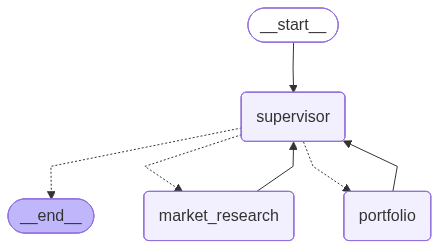

In [6]:
mmd = graph.get_graph().draw_mermaid()
import os
os.makedirs('../docs', exist_ok=True)
open('../docs/graph_phase2.mmd', 'w').write(mmd)
print(mmd)
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print('(PNG render unavailable — Mermaid text above is the source)')

## ✅ Acceptance check

In [10]:
assert agents1 == ['portfolio'], f'Q1 should hit only portfolio, got {agents1}'
assert agents2 == ['market_research'], f'Q2 should hit only market_research, got {agents2}'
assert agents3[:2] == ['portfolio', 'market_research'], f'Q3 should hit both in order, got {agents3}'
print('Phase 2 acceptance: PASS')

Phase 2 acceptance: PASS
